In [1]:
import json
import math
import xml.etree.ElementTree as ET
import os
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np

def readScenario():
    # Load and parse the XML file
    tree = ET.parse('/home/lcastri/git/causal-sim2real/HRISim_docker/src/pedsim_ros/pedsim_simulator/scenarios/warehouse.xml')
    root = tree.getroot()
    
    tmp = {}
    for waypoint in root.findall('waypoint'):
        waypoint_id = waypoint.get('id')
        x = float(waypoint.get('x'))
        y = float(waypoint.get('y'))
        r = float(waypoint.get('r'))
        tmp[waypoint_id] = {'x': x, 'y': y, 'r': r}
    return tmp

def pathLength(task, wps_coord):
    return np.sum([
        math.sqrt(
            (wps_coord[task['path'][wp_idx]]['x'] - wps_coord[task['path'][wp_idx+1]]['x'])**2 + 
            (wps_coord[task['path'][wp_idx]]['y'] - wps_coord[task['path'][wp_idx+1]]['y'])**2
        )
        for wp_idx in range(len(task['path'])-1)])

In [2]:
INDIR = '/home/lcastri/git/causal-sim2real/HRISim_docker/src/HRISim/postprocessing/hrisim_postprocess/csv'
BAGNAMES = ['EXP_INFERENCE_BATTERY_01', 'EXP_INFERENCE_BATTERY_02', 'EXP_INFERENCE_BATTERY_03', 'EXP_INFERENCE_BATTERY_04', 'EXP_INFERENCE_BATTERY_05']
TOD = 'H1'
BN_COLOR = '#FFD9B3'
CM_COLOR = '#ADD8E6'
FONTSIZE = 20

BAGNAME: EXP_INFERENCE_BATTERY_01, Tasks: 50
Mean GT: 0.5458, Mean BN: 0.2800, Mean CM: 0.2826
BN AE (Absolute Error): 0.2658
CM AE (Absolute Error): 0.2632

BAGNAME: EXP_INFERENCE_BATTERY_02, Tasks: 50
Mean GT: 0.6282, Mean BN: 0.2373, Mean CM: 0.2735
BN AE (Absolute Error): 0.3909
CM AE (Absolute Error): 0.3547

BAGNAME: EXP_INFERENCE_BATTERY_03, Tasks: 50
Mean GT: 0.8267, Mean BN: 0.2268, Mean CM: 0.2632
BN AE (Absolute Error): 0.5999
CM AE (Absolute Error): 0.5635

BAGNAME: EXP_INFERENCE_BATTERY_04, Tasks: 50
Mean GT: 1.0747, Mean BN: 0.2247, Mean CM: 0.2451
BN AE (Absolute Error): 0.8499
CM AE (Absolute Error): 0.8296

BAGNAME: EXP_INFERENCE_BATTERY_05, Tasks: 50
Mean GT: 1.0470, Mean BN: 0.2505, Mean CM: 0.3109
BN AE (Absolute Error): 0.7965
CM AE (Absolute Error): 0.7361


=== RESULTS SUMMARY ===
   obstacle_prob    mae_bn    mae_cm    std_bn    std_cm   rmse_bn   rmse_cm
0             10  0.357525  0.357689  0.273576  0.272516  0.450187  0.449673
1             20  0.447434  0.4

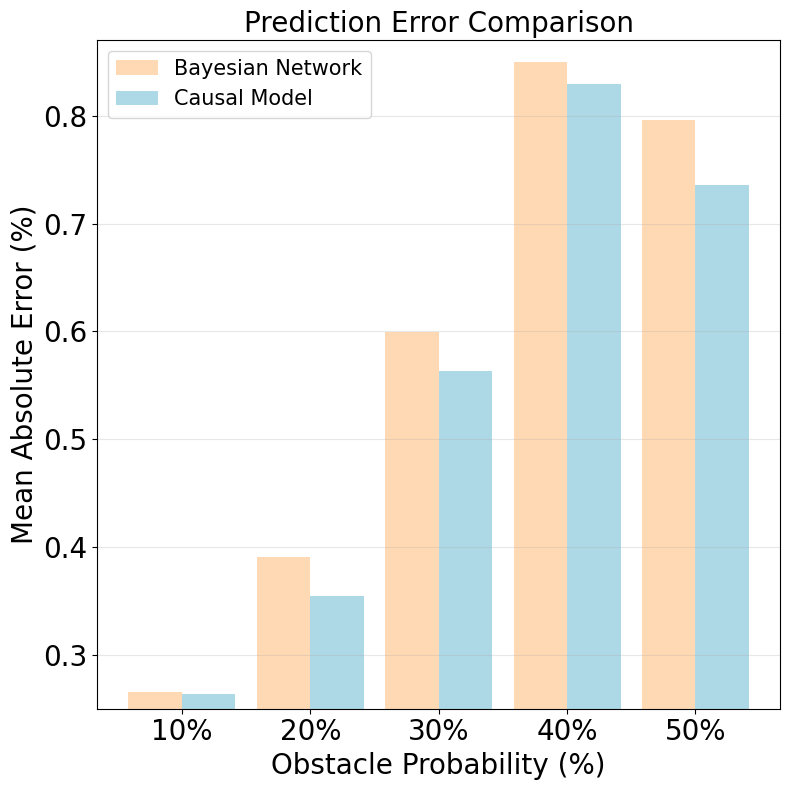

In [3]:
WPS_COORD = readScenario()

# Dictionary to store results across all obstacle levels
results = {
    'obstacle_prob': [],
    'mae_bn': [],
    'mae_cm': [],
    'std_bn': [],
    'std_cm': [],
    'rmse_bn': [],
    'rmse_cm': []
}

for BAGNAME in BAGNAMES:
    with open(os.path.join(INDIR, BAGNAME, f'tasks-{TOD}.json')) as pkl_file:
        TASKS = json.load(pkl_file)
    TASK_IDs = list(range(TASKS['n_tasks']))
            
    df = pd.read_csv(os.path.join(INDIR, BAGNAME, f"{BAGNAME}.csv"))

    DTASKS = {task_id: {'path_length': 0,
                    'duration': 0,
                    'battery_cost_actual': 0,
                    'battery_cost_bn': 0,
                    'battery_cost_cm': 0} for task_id in TASK_IDs}
    for task_id in TASK_IDs:
        
        start_time = TASKS[str(task_id)]['start']
        end_time = TASKS[str(task_id)]['end']
                    
        # Filter the data for the task based on the start and end time
        task_df = df[(df['ros_time'] >= start_time) & (df['ros_time'] <= end_time)]
        
        ## path length
        DTASKS[task_id]['path_length'] = pathLength(TASKS[str(task_id)], WPS_COORD)
        
        ## actual battery consumption
        battery = task_df['R_B'].to_numpy()
        DTASKS[task_id]['battery_cost_actual'] = battery[0] - battery[-1]
        
        ## estimated battery consumption BN
        DTASKS[task_id]['battery_cost_bn'] = TASKS[str(task_id)]['battery_cost_bn']
        
        # estimated battery consumption CM
        DTASKS[task_id]['battery_cost_cm'] = TASKS[str(task_id)]['battery_cost_cm']
        
        ## duration
        DTASKS[task_id]['duration'] = end_time - start_time
        
        if battery[0] - battery[-1] < -5 or battery[0] - battery[-1] == 0: 
            print(f"Removing task {task_id} with battery consumption {battery[0] - battery[-1]}")
            del DTASKS[task_id]
        
    print(f"BAGNAME: {BAGNAME}, Tasks: {len(DTASKS)}")

    gt = []
    bn = []
    cm = []
    for task_id, task_info in DTASKS.items():
        gt.append(task_info['battery_cost_actual'])
        bn.append(task_info['battery_cost_bn'])
        cm.append(task_info['battery_cost_cm'])
    
    # Compute metrics
    mean_gt = np.mean(gt)
    mean_bn = np.mean(bn)
    mean_cm = np.mean(cm)
    print(f"Mean GT: {mean_gt:.4f}, Mean BN: {mean_bn:.4f}, Mean CM: {mean_cm:.4f}")
    print(f"BN AE (Absolute Error): {np.abs(mean_gt - mean_bn):.4f}")
    print(f"CM AE (Absolute Error): {np.abs(mean_gt - mean_cm):.4f}")
    
    mae_bn = np.mean(np.abs(np.array(gt) - np.array(bn)))
    mae_cm = np.mean(np.abs(np.array(gt) - np.array(cm)))
    std_bn = np.std(np.abs(np.array(gt) - np.array(bn)))
    std_cm = np.std(np.abs(np.array(gt) - np.array(cm)))
    rmse_bn = np.sqrt(np.mean((np.array(gt) - np.array(bn))**2))
    rmse_cm = np.sqrt(np.mean((np.array(gt) - np.array(cm))**2))
    
    # Extract obstacle probability from BAGNAME (e.g., 'EXP_INFERENCE_BATTERY_01' -> 10%)
    bag_idx = int(BAGNAME.split('_')[-1])
    obstacle_prob = bag_idx * 10  # 1->10%, 2->20%, etc.
    
    # Store results
    results['obstacle_prob'].append(obstacle_prob)
    results['mae_bn'].append(mae_bn)
    results['mae_cm'].append(mae_cm)
    results['std_bn'].append(std_bn)
    results['std_cm'].append(std_cm)
    results['rmse_bn'].append(rmse_bn)
    results['rmse_cm'].append(rmse_cm)
    
    # print(f"  MAE_BN: {mae_bn:.4f} ± {std_bn:.4f}")
    # print(f"  MAE_CM: {mae_cm:.4f} ± {std_cm:.4f}")
    # print(f"  RMSE_BN: {rmse_bn:.4f}")
    # print(f"  RMSE_CM: {rmse_cm:.4f}")
    print()

# Create a results DataFrame for easier visualization
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('obstacle_prob')
print("\n=== RESULTS SUMMARY ===")
print(results_df)


import matplotlib.pyplot as plt
import numpy as np

labels = ['10%', '20%', '30%', '40%', '50%']
bn_ae = [0.2658, 0.3909, 0.5999, 0.8499, 0.7965]
cm_ae = [0.2632, 0.3547, 0.5635, 0.8296, 0.7361]

x = np.arange(len(labels))*0.6
width = 0.25

fig, ax = plt.subplots(figsize=(8, 8))
rects1 = ax.bar(x - width/2, bn_ae, width, label='Bayesian Network', color=BN_COLOR, alpha=1.0)
rects2 = ax.bar(x + width/2, cm_ae, width, label='Causal Model', color=CM_COLOR, alpha=1.0)

ax.set_ylabel('Mean Absolute Error (%)', fontsize=FONTSIZE)
ax.set_xlabel('Obstacle Probability (%)', fontsize=FONTSIZE)
ax.set_title('Prediction Error Comparison', fontsize=FONTSIZE)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=FONTSIZE)
ax.tick_params(axis='y', labelsize=FONTSIZE)
ax.grid(axis='y', alpha=0.3)
ax.legend(fontsize=15)
ax.set_ylim(0.25, 0.87)

plt.tight_layout()
plt.show()

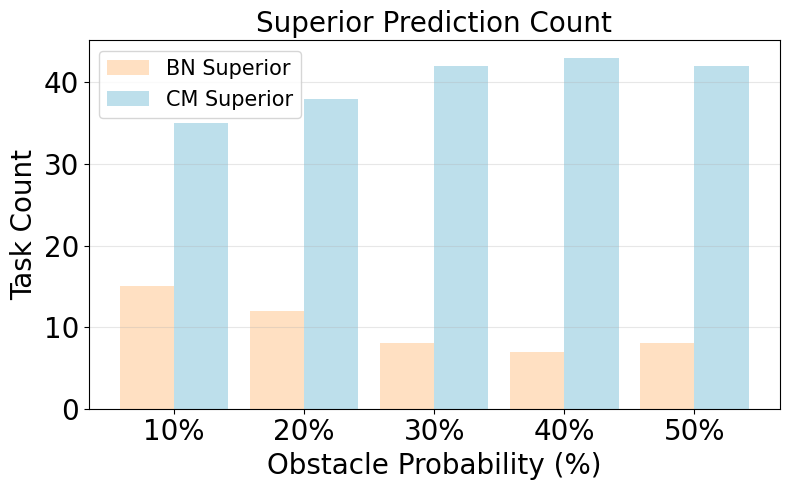

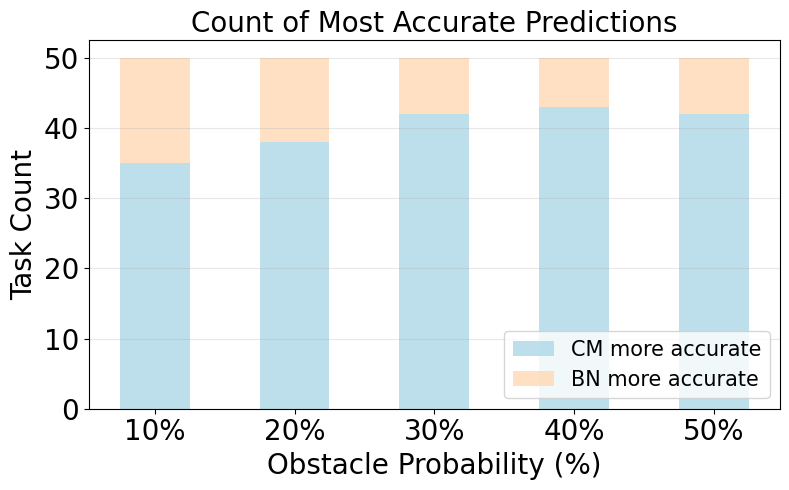

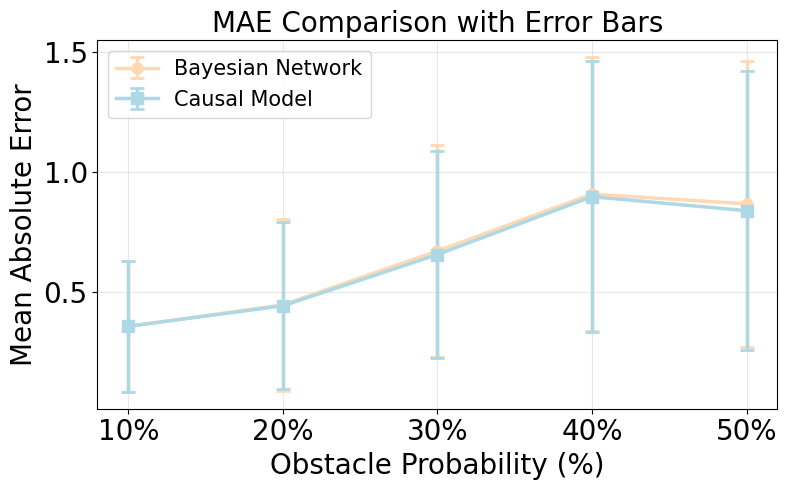


=== PER-TASK ACCURACY SUMMARY ===
Total tasks analyzed: 250
CM wins: 200 (80.0%)
BN wins: 50 (20.0%)
Ties: 0 (0.0%)

CM consistently better: True

Win rate by obstacle level:
obstacle_prob  winner
10             BN        15
               CM        35
20             BN        12
               CM        38
30             BN         8
               CM        42
40             BN         7
               CM        43
50             BN         8
               CM        42
Name: count, dtype: int64


In [4]:
# Per-task comparison: Count how many times CM is better than BN

cm_wins = 0
bn_wins = 0
ties = 0
task_results = []

for BAGNAME in BAGNAMES:
    with open(os.path.join(INDIR, BAGNAME, f'tasks-{TOD}.json')) as pkl_file:
        TASKS = json.load(pkl_file)
    TASK_IDs = list(range(TASKS['n_tasks']))
    
    df = pd.read_csv(os.path.join(INDIR, BAGNAME, f"{BAGNAME}.csv"))

    DTASKS = {task_id: {'battery_cost_actual': 0,
                    'battery_cost_bn': 0,
                    'battery_cost_cm': 0} for task_id in TASK_IDs}
    
    for task_id in TASK_IDs:
        start_time = TASKS[str(task_id)]['start']
        end_time = TASKS[str(task_id)]['end']
        task_df = df[(df['ros_time'] >= start_time) & (df['ros_time'] <= end_time)]
        
        battery = task_df['R_B'].to_numpy()
        DTASKS[task_id]['battery_cost_actual'] = battery[0] - battery[-1]
        DTASKS[task_id]['battery_cost_bn'] = TASKS[str(task_id)]['battery_cost_bn']
        DTASKS[task_id]['battery_cost_cm'] = TASKS[str(task_id)]['battery_cost_cm']
        
        # Skip invalid tasks
        if battery[0] - battery[-1] < -5 or battery[0] - battery[-1] == 0:
            continue
    
    # Extract obstacle probability
    bag_idx = int(BAGNAME.split('_')[-1])
    obstacle_prob = bag_idx * 10
    
    # Compare predictions
    for task_id, task_info in DTASKS.items():
        gt = task_info['battery_cost_actual']
        bn_pred = task_info['battery_cost_bn']
        cm_pred = task_info['battery_cost_cm']
        
        error_bn = abs(gt - bn_pred)
        error_cm = abs(gt - cm_pred)
        
        task_results.append({
            'obstacle_prob': obstacle_prob,
            'task_id': task_id,
            'gt': gt,
            'bn_pred': bn_pred,
            'cm_pred': cm_pred,
            'error_bn': error_bn,
            'error_cm': error_cm,
            'winner': 'CM' if error_cm < error_bn else ('BN' if error_bn < error_cm else 'TIE')
        })
        
        if error_cm < error_bn:
            cm_wins += 1
        elif error_bn < error_cm:
            bn_wins += 1
        else:
            ties += 1

# Create results dataframe for detailed analysis
tasks_df = pd.DataFrame(task_results)

# Create visualization
fig, ax2 = plt.subplots(figsize=(8, 5))

# Plot: Win rate by obstacle probability
win_by_obstacle = tasks_df.groupby('obstacle_prob')['winner'].value_counts().unstack(fill_value=0)
if 'TIE' not in win_by_obstacle.columns:
    win_by_obstacle['TIE'] = 0

x = np.arange(len(win_by_obstacle))*0.6
width = 0.25

if 'BN' in win_by_obstacle.columns:
    ax2.bar(x - width/2, win_by_obstacle['BN'], width, label='BN Superior', color=BN_COLOR, alpha=0.8)
if 'CM' in win_by_obstacle.columns:
    ax2.bar(x + width/2, win_by_obstacle['CM'], width, label='CM Superior', color=CM_COLOR, alpha=0.8)

ax2.set_xlabel('Obstacle Probability (%)', fontsize=FONTSIZE)
ax2.set_ylabel('Task Count', fontsize=FONTSIZE)
ax2.set_title('Superior Prediction Count', fontsize=FONTSIZE)
ax2.set_xticks(x)
ax2.set_xticklabels(win_by_obstacle.index.astype(int).astype(str) + '%')
ax2.tick_params(axis='x', labelsize=FONTSIZE)
ax2.tick_params(axis='y', labelsize=FONTSIZE)

ax2.legend(fontsize=15, loc='upper left')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Create stacked bar chart showing proportions
fig, ax3 = plt.subplots(figsize=(8, 5))

# Calculate proportions for each obstacle level
win_by_obstacle_prop = win_by_obstacle.div(win_by_obstacle.sum(axis=1), axis=0)

# Prepare data for stacked bar chart
x = np.arange(len(win_by_obstacle_prop))
width = 0.5

# Scale to 50 for visualization (total bar height = 50 per category)
scale_factor = 50
bn_values = win_by_obstacle_prop['BN'].values * scale_factor if 'BN' in win_by_obstacle_prop.columns else np.zeros(len(win_by_obstacle_prop))
cm_values = win_by_obstacle_prop['CM'].values * scale_factor if 'CM' in win_by_obstacle_prop.columns else np.zeros(len(win_by_obstacle_prop))

# Create stacked bars
p2 = ax3.bar(x, cm_values, width, label='CM more accurate', color=CM_COLOR, alpha=0.8)
p1 = ax3.bar(x, bn_values, width, bottom=cm_values, label='BN more accurate', color=BN_COLOR, alpha=0.8)

ax3.set_xlabel('Obstacle Probability (%)', fontsize=FONTSIZE)
ax3.set_ylabel('Task Count', fontsize=FONTSIZE)
ax3.set_title('Count of Most Accurate Predictions', fontsize=FONTSIZE)
ax3.set_xticks(x)
ax3.set_xticklabels(win_by_obstacle_prop.index.astype(int).astype(str) + '%', fontsize=FONTSIZE)
ax3.tick_params(axis='y', labelsize=FONTSIZE)
ax3.legend(fontsize=15, loc='lower right')
ax3.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Line graph with error bars
fig, ax4 = plt.subplots(figsize=(8, 5))

ax4.errorbar(results_df['obstacle_prob'], results_df['mae_bn'], yerr=results_df['std_bn'], 
             fmt='o-', label='Bayesian Network', color=BN_COLOR, linewidth=2.5, markersize=8, capsize=5, capthick=2)
ax4.errorbar(results_df['obstacle_prob'], results_df['mae_cm'], yerr=results_df['std_cm'], 
             fmt='s-', label='Causal Model', color=CM_COLOR, linewidth=2.5, markersize=8, capsize=5, capthick=2)

ax4.set_xlabel('Obstacle Probability (%)', fontsize=FONTSIZE)
ax4.set_ylabel('Mean Absolute Error', fontsize=FONTSIZE)
ax4.set_title('MAE Comparison with Error Bars', fontsize=FONTSIZE)
ax4.set_xticks(results_df['obstacle_prob'])
ax4.set_xticklabels(results_df['obstacle_prob'].astype(int).astype(str) + '%', fontsize=FONTSIZE)
ax4.tick_params(axis='y', labelsize=FONTSIZE)
ax4.legend(fontsize=15)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary
print("\n=== PER-TASK ACCURACY SUMMARY ===")
print(f"Total tasks analyzed: {cm_wins + bn_wins + ties}")
print(f"CM wins: {cm_wins} ({cm_wins/(cm_wins+bn_wins+ties)*100:.1f}%)")
print(f"BN wins: {bn_wins} ({bn_wins/(cm_wins+bn_wins+ties)*100:.1f}%)")
print(f"Ties: {ties} ({ties/(cm_wins+bn_wins+ties)*100:.1f}%)")
print(f"\nCM consistently better: {cm_wins > bn_wins}")
print(f"\nWin rate by obstacle level:")
print(tasks_df.groupby('obstacle_prob')['winner'].value_counts().sort_index())